# Plot generator
Put this notebook in the same folder as your phyphox measurements. Assuming delimiter is comma, it will plot every column.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib

['Time (s)', 'w', 'x', 'y', 'z', 'Direct (°)', 'Yaw (°)', 'Pitch (°)', 'Roll (°)']


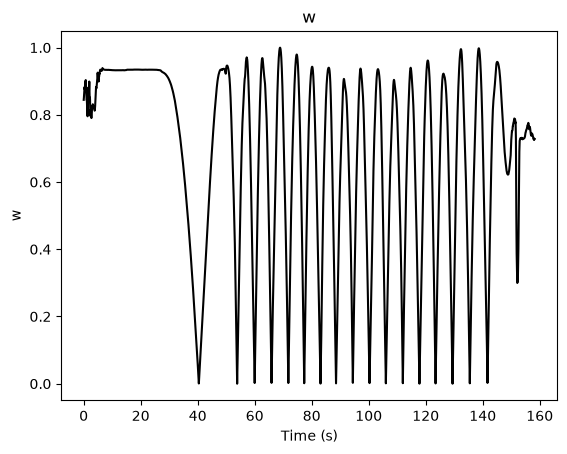

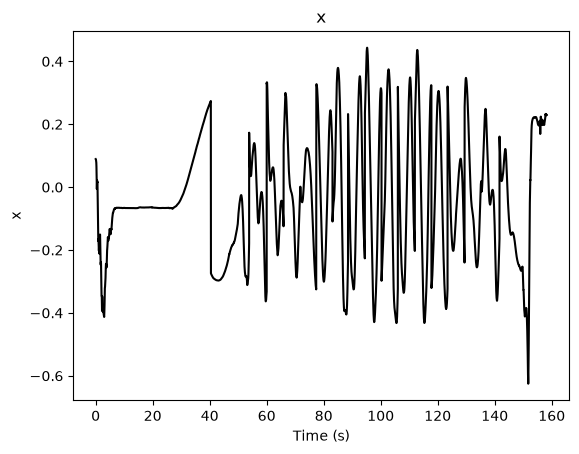

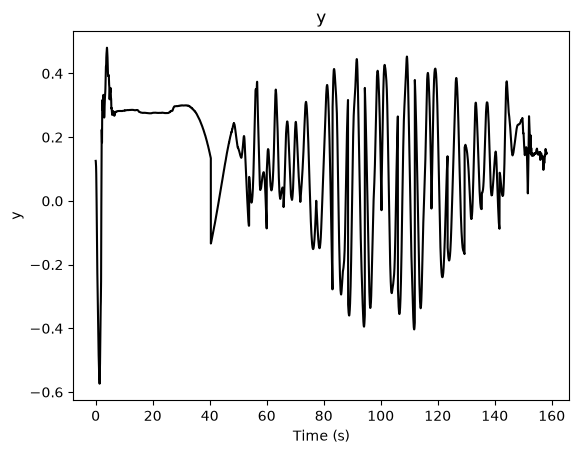

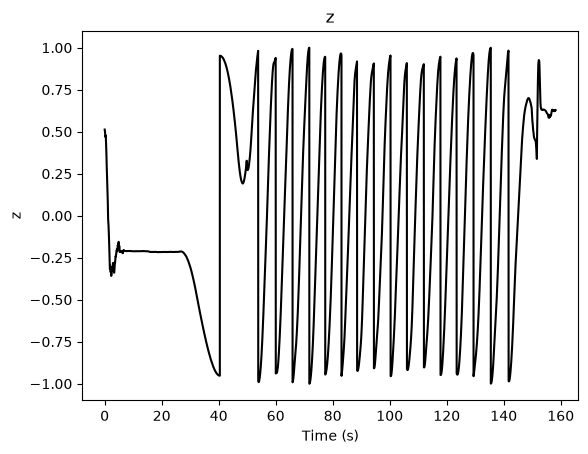

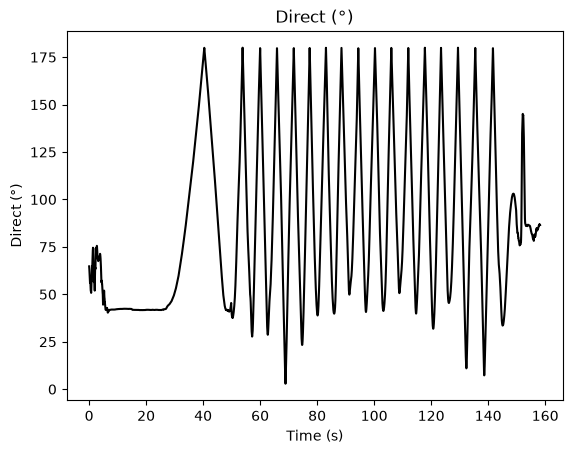

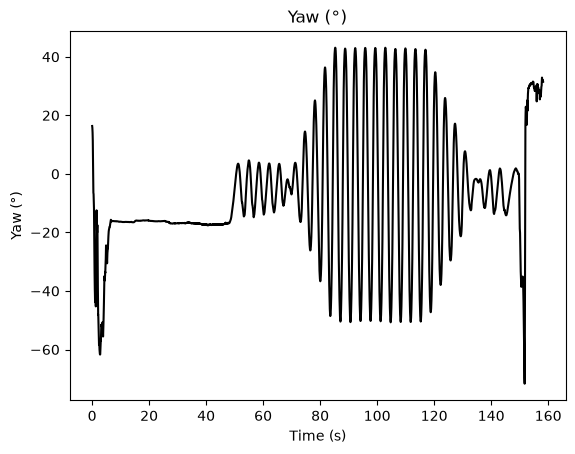

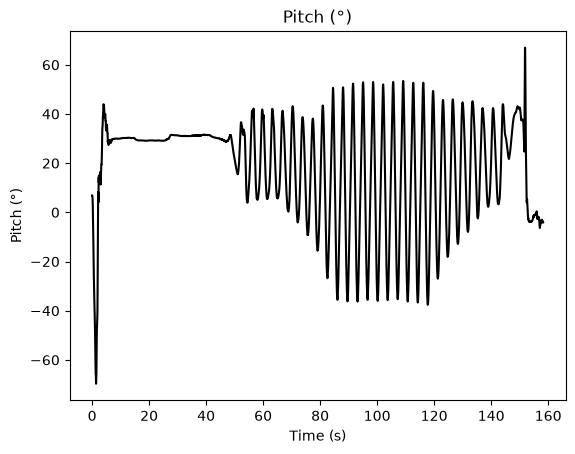

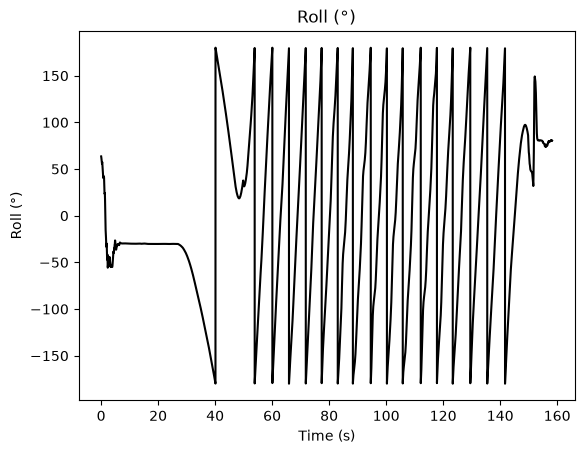

['Time (s)', 'Latitude (°)', 'Longitude (°)', 'Height (m)', 'Velocity (m/s)', 'Direction (°)', 'Horizontal Accuracy (m)', 'Vertical Accuracy (°)']


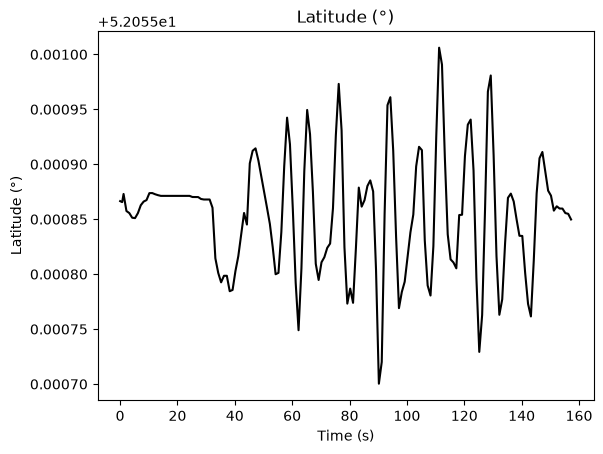

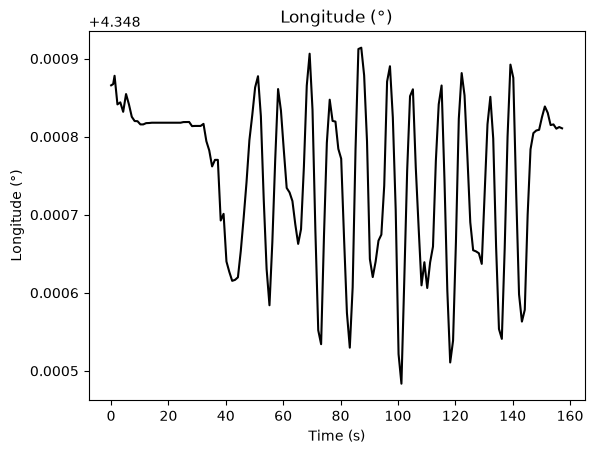

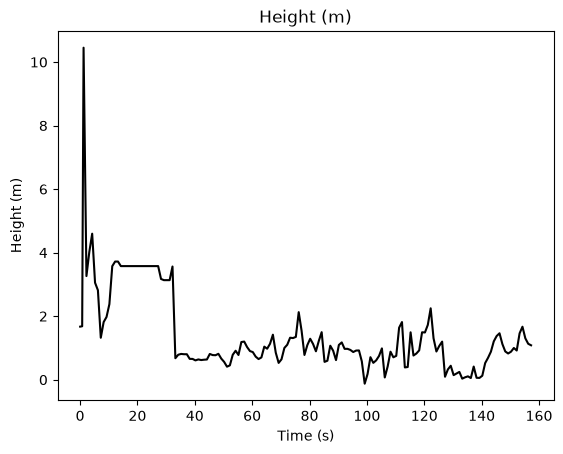

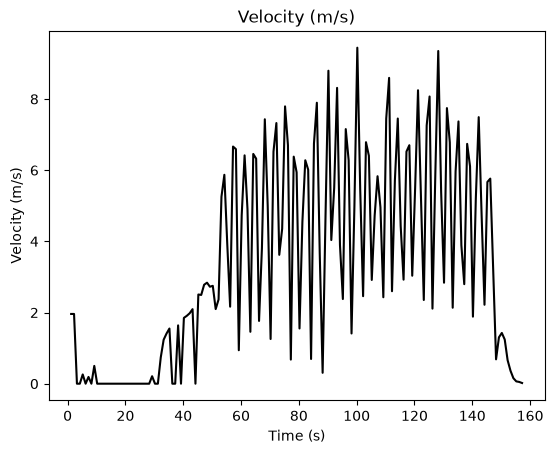

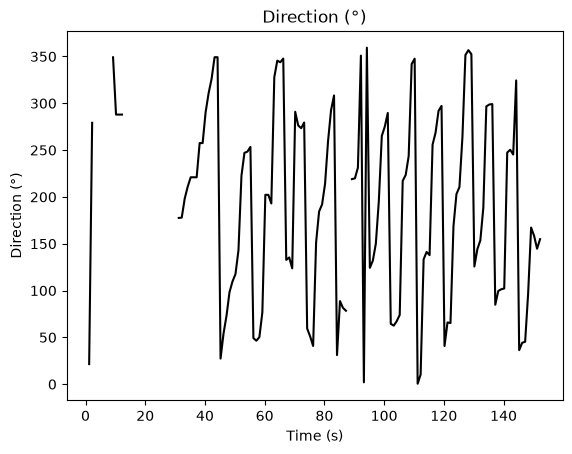

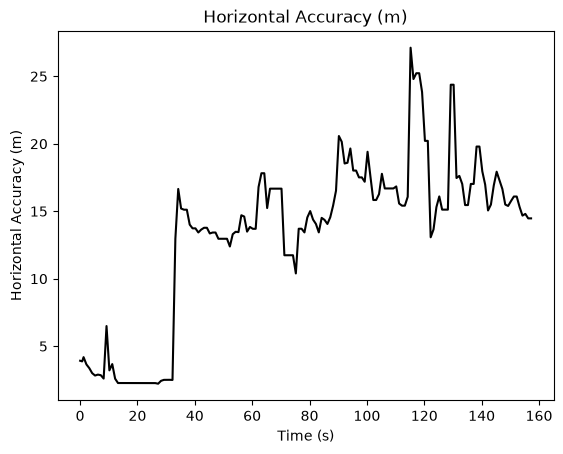

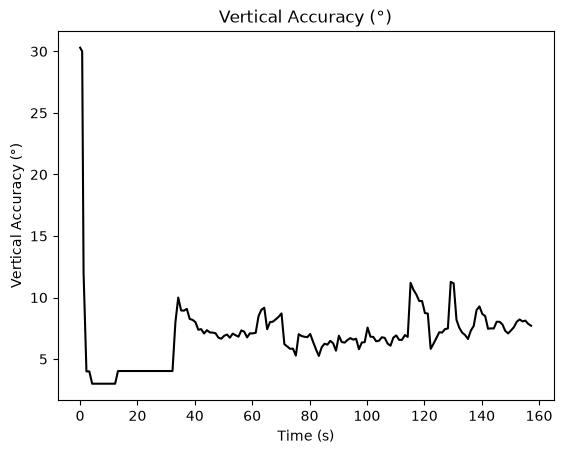

['Time (s)', 'X (rad/s)', 'Y (rad/s)', 'Z (rad/s)']


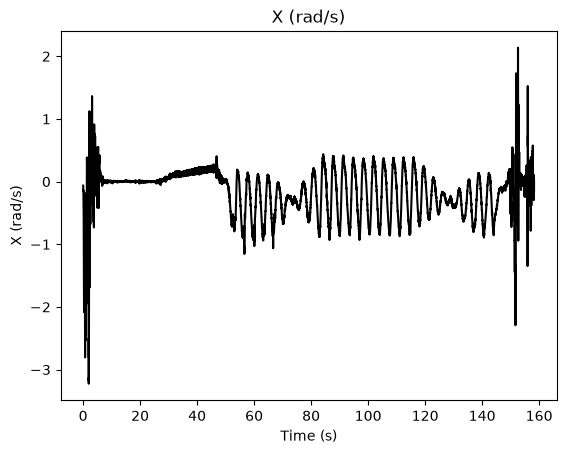

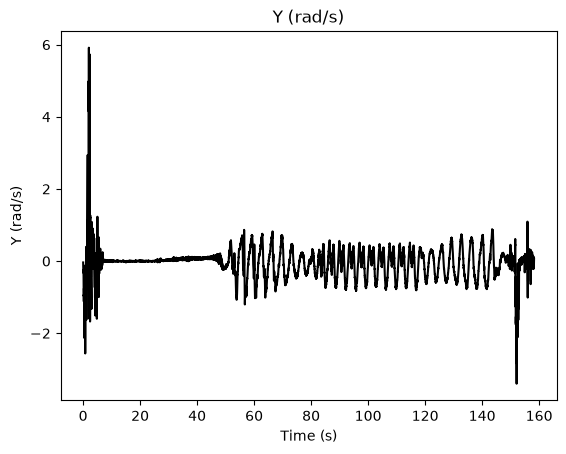

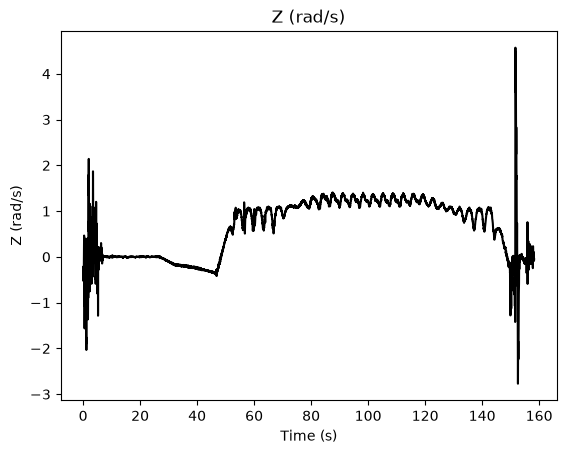

['Time (s)', 'Gravity X (m/s^2)', 'Gravity Y (m/s^2)', 'Gravity Z (m/s^2)']


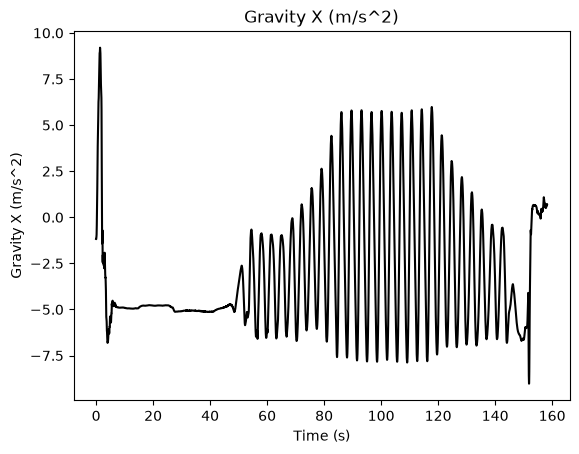

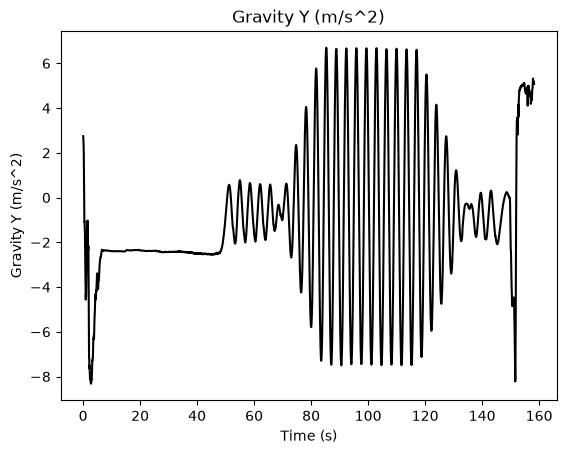

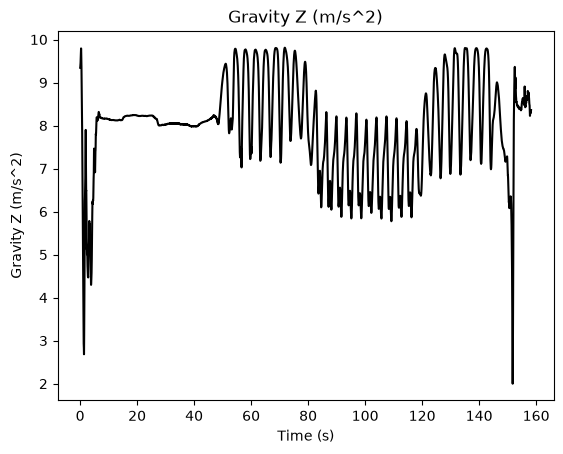

['Time (s)', 'X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)']


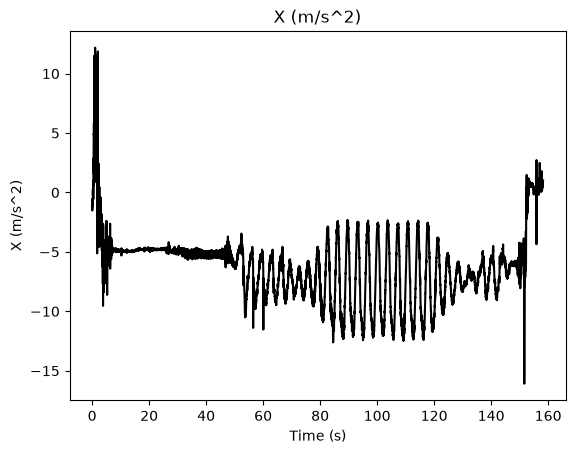

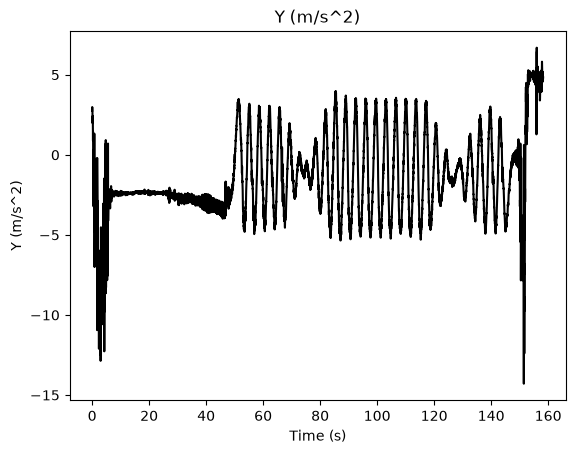

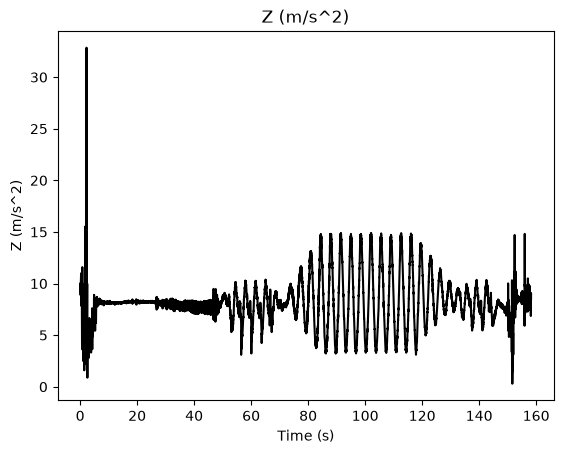

In [2]:
files = ["Orientation.csv", "Location.csv", "Gyroscope.csv", "Gravity.csv", "Accelerometer.csv"]

def plotcsv(filename):
    # Get the CSV filename without ".csv"
    csv_name = pathlib.Path(filename).stem
    
    # Create a folder for this CSV
    plot_folder = pathlib.Path("plots") / csv_name
    plot_folder.mkdir(parents=True, exist_ok=True)

    with open(filename, encoding='utf-8') as file:
    
        headers = file.readline()
        headers = headers.replace('"', '')
        headers = headers.split(',')
        headers = [header.strip() for header in headers]
        print(headers)
    
        data = np.loadtxt(file, delimiter=',')
    
        # Skip column 0 because it contains time
        for i, column in enumerate(data.T[1:], start=1):
            plt.figure()
            plt.plot(data[:, 0], column, 'k-', markersize=2)
            plt.xlabel(headers[0])
            plt.ylabel(headers[i])
            plt.title(headers[i])

            # Save the plot
            plot_name = safe_filename(headers[i])
            plot_file = plot_folder / f"{plot_name}.png"
            plt.savefig(plot_file)

            plt.show()
            plt.close()


def prep_plot_folder():
    directory = pathlib.Path("plots")
    directory.mkdir(exist_ok=True)

def safe_filename(name):
    name = name.strip()
    
    # Characters that Windows does not allow in filenames 
    invalid_chars = '<>:"/\\|?*' 
    for char in invalid_chars:
        name = name.replace(char, '_') 
        
    return name

prep_plot_folder()

for file in files:
    plotcsv(file)